# SHAP Analysis: Model Explainability and Drift Detection

**Docker image**: `ml4t`

**Chapter 12, Section 12.5**: Model Explainability with SHAP

## Purpose
This notebook demonstrates SHAP (SHapley Additive exPlanations) for
interpreting GBM predictions on financial data. TreeSHAP provides exact
Shapley values in polynomial time, enabling routine model diagnostics.

## Learning Objectives
- Compute global and local SHAP explanations for LightGBM models
- Analyze feature interactions via SHAP interaction values
- Compare SHAP, PFI, and MDI importance rankings for consensus
- Detect feature drift across walk-forward folds
- Use SHAP-based feature selection to prune and retrain

## Cross-References
- **Section 12.5**: SHAP theory, interaction decomposition, drift monitoring
- **Section 11.4**: SHAP introduction, dependence plots
- **Chapter 23**: Production monitoring systems
- **Related**: `09_xai_limitations` (explanation instability), `11_conformal_gbm` (UQ)

## References
- Lundberg & Lee (2017). "A Unified Approach to Interpreting Model Predictions"
- Lundberg et al. (2020). "From Local Explanations to Global Understanding with Explainable AI for Trees"

## 1. Setup

In [1]:
"""SHAP Analysis — demonstrate model explainability and feature drift detection for GBMs."""

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

import lightgbm as lgb
import shap
from ml4t.diagnostic.metrics import cross_sectional_ic_series

from case_studies.utils.analytics import PRIMARY_LABELS, SHORT_NAMES
from utils.modeling import load_modeling_dataset
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS


def cross_sectional_ic_mean(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dates: np.ndarray,
    symbols: np.ndarray,
) -> float:
    """Mean cross-sectional Spearman IC across dates in a fold."""
    pred_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
    )
    ic_clean = ic_per_date.drop_nulls("ic")
    return float(ic_clean["ic"].mean()) if ic_clean.height else float("nan")

In [2]:
MAX_SYMBOLS = 0  # 0 = all symbols
SEED = 42
# Repo-root-anchored (matches sibling chapter notebooks) so the artifact lands in
# 12_gradient_boosting/output/shap_analysis regardless of the kernel's working
# directory — a raw relative Path resolves against the notebook dir under nbconvert
# and produces a stray nested 12_gradient_boosting/12_gradient_boosting/ tree.
OUTPUT_DIR = get_output_dir(12, "shap_analysis")

In [3]:
set_global_seeds(SEED)

## 2. Load Data

In [4]:
mds = load_modeling_dataset("etfs", "fwd_ret_21d")
df = mds.dataset.to_pandas()
date_col = mds.date_col
FEATURE_COLS = mds.feature_names

# Use first walk-forward fold
split = mds.splits[0]
train_mask = (df[date_col] >= split["train_start"]) & (df[date_col] <= split["train_end"])
test_mask = (df[date_col] >= split["val_start"]) & (df[date_col] <= split["val_end"])

X_train = df.loc[train_mask, FEATURE_COLS].values
y_train = df.loc[train_mask, mds.label_col].values
X_test = df.loc[test_mask, FEATURE_COLS].values
y_test = df.loc[test_mask, mds.label_col].values

# Drop NaN labels
train_valid = np.isfinite(y_train)
test_valid = np.isfinite(y_test)
X_train, y_train = X_train[train_valid], y_train[train_valid]
X_test, y_test = X_test[test_valid], y_test[test_valid]

# Keep test dates and symbols for drift analysis and cross-sectional IC
test_entity_col = mds.entity_cols[0]
dates_test = df.loc[test_mask, date_col].values[test_valid]
symbols_test = df.loc[test_mask, test_entity_col].values[test_valid]

print(f"ETFs: {len(X_train):,} train / {len(X_test):,} test ({len(FEATURE_COLS)} features)")

ETFs: 227,101 train / 24,190 test (71 features)


## 3. Train LightGBM Model

In [5]:
lgb_params = {
    "n_estimators": 100,
    "max_depth": 4,
    "learning_rate": 0.1,
    "num_leaves": 15,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": SEED,
    "verbose": -1,
}

model = lgb.LGBMRegressor(**lgb_params)
model.fit(X_train, y_train)

LGBMRegressor(colsample_bytree=0.8, max_depth=4, num_leaves=15, random_state=42,
              subsample=0.8, verbose=-1)

## 4. SHAP Value Computation

TreeSHAP computes exact Shapley values in $O(TLD^2)$ time, where $T$ is
the number of trees, $L$ the number of leaves, and $D$ the tree depth.

In [6]:
explainer = shap.TreeExplainer(model)
shap_values_test = explainer.shap_values(X_test)

## 5. SHAP Beeswarm Plot

The beeswarm plot shows how each feature's SHAP values are distributed
across the test set. Each dot represents one sample; horizontal position
shows the SHAP value, and color encodes the raw feature value.

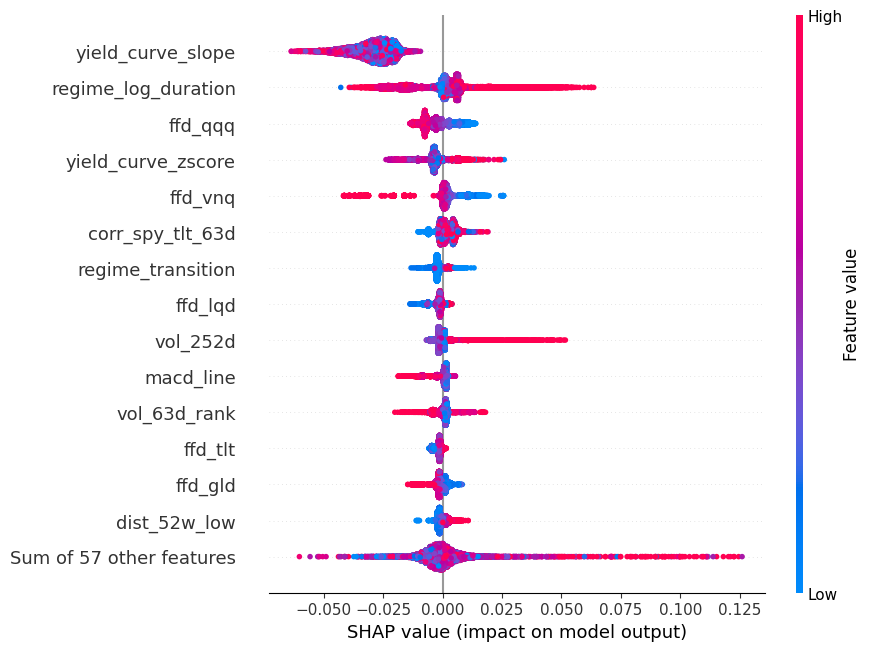

In [7]:
explanation = shap.Explanation(
    values=shap_values_test,
    base_values=np.full(len(shap_values_test), explainer.expected_value),
    data=X_test,
    feature_names=FEATURE_COLS,
)

shap.plots.beeswarm(explanation, max_display=15, show=False)
plt.show()

**Interpretation**: Features at the top contribute most to predictions on
average. The color gradient reveals non-linearities: if high feature values
(red dots) cluster on one side while low values (blue) cluster on the other,
the feature has a monotonic relationship with the prediction.

## 6. Global Feature Importance

Mean |SHAP| ranks features by their average contribution magnitude
across all predictions.

In [8]:
mean_abs_shap = np.abs(shap_values_test).mean(axis=0)
importance_df = pl.DataFrame({"feature": FEATURE_COLS, "mean_abs_shap": mean_abs_shap}).sort(
    "mean_abs_shap", descending=True
)
importance_df

feature,mean_abs_shap
str,f64
"""yield_curve_slope""",0.029237
"""regime_log_duration""",0.009792
"""ffd_qqq""",0.005485
"""yield_curve_zscore""",0.004319
"""ffd_vnq""",0.003872
…,…
"""sharpe_5d""",0.000002
"""obv_zscore_63d""",6.9915e-7
"""sharpe_42d""",0.0


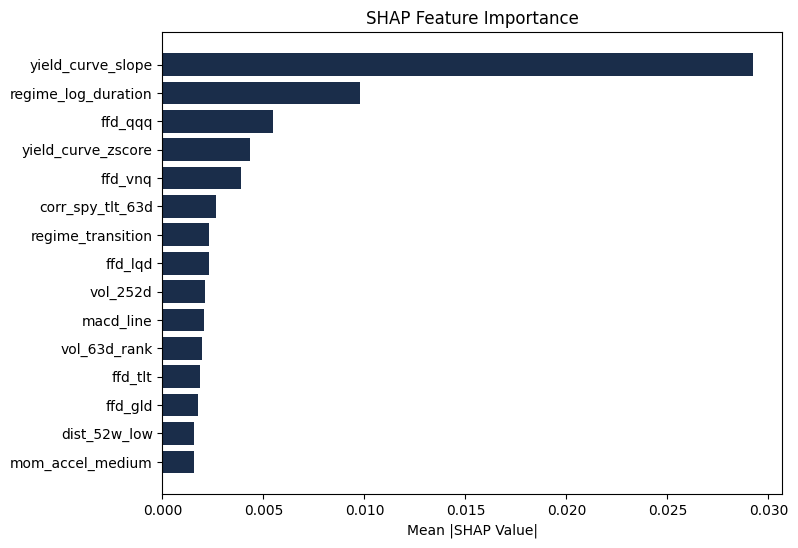

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
top_n_display = min(15, len(importance_df))
plot_df = importance_df.head(top_n_display)
ax.barh(
    range(top_n_display),
    plot_df["mean_abs_shap"].reverse().to_list(),
    color=COLORS["slate"],
)
ax.set_yticks(range(top_n_display))
ax.set_yticklabels(plot_df["feature"].reverse().to_list())
ax.set_xlabel("Mean |SHAP Value|")
ax.set_title("SHAP Feature Importance")
plt.show()

## 7. Feature Importance Consensus

Comparing SHAP against permutation importance (PFI) and mean decrease
in impurity (MDI) identifies features that are robustly important
across methods.

| Method | Approach | Strengths |
|--------|----------|-----------|
| **MDI** | Tree splits | Fast, but biased toward high-cardinality |
| **PFI** | Shuffle features | Model-agnostic, measures true importance |
| **SHAP** | Game-theoretic | Consistent, explains individual predictions |

In [10]:
# MDI: built-in feature importance
mdi_importance = model.feature_importances_

# PFI: permutation feature importance
pfi_result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=SEED)
pfi_importance = pfi_result.importances_mean

In [11]:
# Build rankings
rankings = {}
for method_name, values in [
    ("MDI", mdi_importance),
    ("PFI", pfi_importance),
    ("SHAP", mean_abs_shap),
]:
    order = np.argsort(values)[::-1]
    rankings[method_name] = [FEATURE_COLS[i] for i in order]

consensus_df = pl.DataFrame(
    {
        "rank": list(range(1, min(15, len(FEATURE_COLS)) + 1)),
        "MDI": rankings["MDI"][:15],
        "PFI": rankings["PFI"][:15],
        "SHAP": rankings["SHAP"][:15],
    }
)
consensus_df

rank,MDI,PFI,SHAP
i64,str,str,str
1,"""regime_log_duration""","""regime_log_duration""","""yield_curve_slope"""
2,"""yield_curve_slope""","""yield_curve_slope""","""regime_log_duration"""
3,"""corr_spy_tlt_63d""","""ffd_vnq""","""ffd_qqq"""
4,"""vol_252d""","""yield_curve_zscore""","""yield_curve_zscore"""
5,"""yield_curve_zscore""","""mom_accel_long""","""ffd_vnq"""
…,…,…,…
11,"""regime_prob_stress""","""regime_transition""","""vol_63d_rank"""
12,"""ffd_tlt""","""ffd_efa""","""ffd_tlt"""
13,"""ffd_vnq""","""macd_line""","""ffd_gld"""


**Interpretation**: Features appearing in the top ranks across all three
methods are robustly important. MDI-only high ranks often reflect high
cardinality; PFI captures interactions missed by splits; SHAP captures
non-linear effects.

## 8. Local Explanation

SHAP explains individual predictions by showing how each feature pushes
the prediction away from the expected (baseline) value.

In [12]:
idx = 0
prediction = model.predict(X_test[idx : idx + 1])[0]
expected_value = explainer.expected_value
shap_vals = shap_values_test[idx]

local_df = pl.DataFrame(
    {
        "feature": FEATURE_COLS,
        "shap_value": shap_vals,
        "feature_value": X_test[idx],
    }
).sort("shap_value", descending=True)

The waterfall below shows how feature contributions accumulate from the
baseline to the final prediction.

In [13]:
local_df

feature,shap_value,feature_value
str,f64,f64
"""regime_log_duration""",0.012536,5.613128
"""ffd_qqq""",0.012145,0.195814
"""regime_transition""",0.00724,0.000003
"""regime_prob_stress""",0.002748,1.0
"""ffd_spy""",0.002638,0.222559
…,…,…
"""ffd_tlt""",-0.001288,0.070591
"""ffd_gld""",-0.001548,0.200645
"""ret_63d""",-0.002067,0.093394


In [14]:
print(f"Baseline: {expected_value:.4f} → Prediction: {prediction:.4f} (Actual: {y_test[idx]:.4f})")

Baseline: 0.0058 → Prediction: 0.0125 (Actual: 0.0686)


## 9. Dependence Plot

Shows the relationship between a feature value and its SHAP value,
revealing non-linearities and interactions.

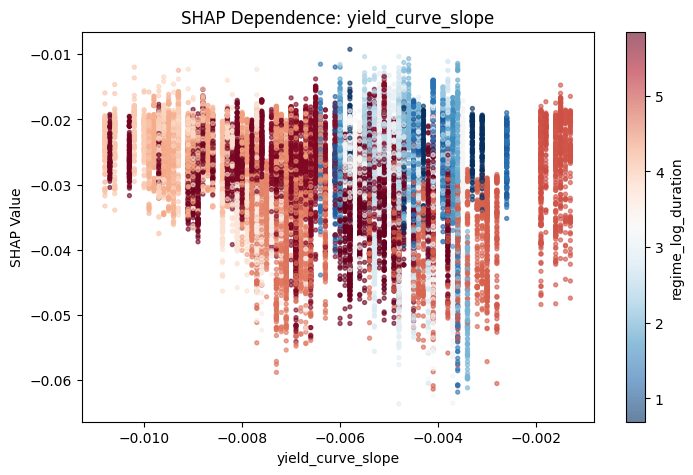

In [15]:
top_feat = importance_df["feature"][0]
second_feat = importance_df["feature"][1]
top_idx = FEATURE_COLS.index(top_feat)
second_idx = FEATURE_COLS.index(second_feat)

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    X_test[:, top_idx],
    shap_values_test[:, top_idx],
    c=X_test[:, second_idx],
    cmap="RdBu_r",
    s=8,
    alpha=0.6,
)
ax.set_xlabel(top_feat)
ax.set_ylabel("SHAP Value")
ax.set_title(f"SHAP Dependence: {top_feat}")
plt.colorbar(scatter, ax=ax, label=second_feat)
fig.subplots_adjust(left=0.12, right=0.92, top=0.9, bottom=0.12)
plt.show()

**Interpretation**: The color gradient reveals how the interaction with
the second feature modulates the SHAP contribution. Where the color
separates vertically at a given feature value, the interaction is active.

## 10. SHAP Interaction Values

TreeSHAP decomposes predictions into main effects and pairwise
interactions:

$$f(x) = E[f(X)] + \sum_{j} \phi_j^{\text{main}} + \sum_{j < k} \phi_{jk}^{\text{interaction}}$$

In [16]:
# Compute interaction values on the full model with a subsample
sample_size = min(200, len(X_test))
TOP_N = min(10, len(FEATURE_COLS))
top_feature_names = importance_df["feature"][:TOP_N].to_list()
top_feature_idxs = [FEATURE_COLS.index(f) for f in top_feature_names]

shap_interaction = explainer.shap_interaction_values(X_test[:sample_size])

# Subset to top features for display
interaction_top = shap_interaction[:, top_feature_idxs, :][:, :, top_feature_idxs]
mean_interaction = np.abs(interaction_top).mean(axis=0)

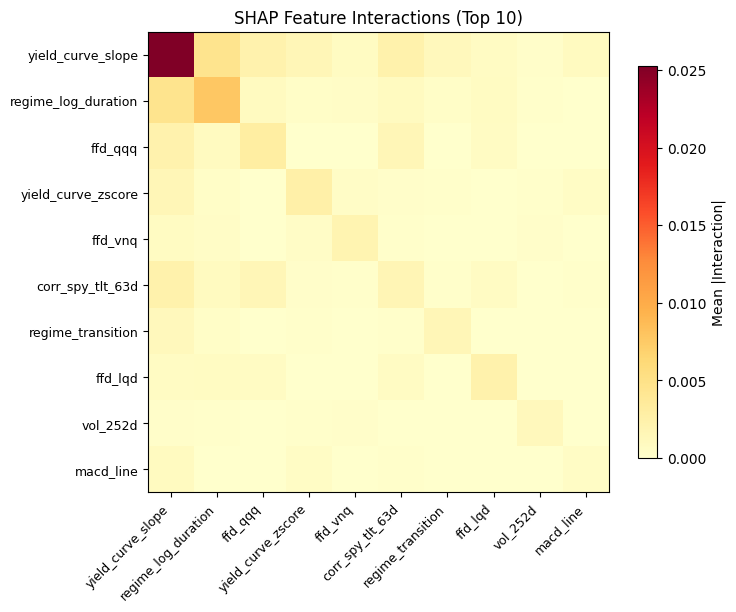

In [17]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(mean_interaction, cmap="YlOrRd", aspect="equal")
ax.set_xticks(range(TOP_N))
ax.set_xticklabels(top_feature_names, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_feature_names, fontsize=9)
ax.set_title(f"SHAP Feature Interactions (Top {TOP_N})")
plt.colorbar(im, ax=ax, label="Mean |Interaction|", shrink=0.8)
fig.subplots_adjust(left=0.18, right=0.9, top=0.9, bottom=0.2)
plt.show()

**Interpretation**: Diagonal entries represent main effects; off-diagonal
entries quantify pairwise interactions. Strong off-diagonal cells indicate
features whose SHAP contributions depend on each other's values — a
signal that the underlying relationship is regime-conditional.

### Approximate Friedman H-Statistic

The H-statistic (Friedman & Popescu, 2008) measures interaction strength
as the fraction of joint effect attributable to the interaction. Values
above 0.1 indicate meaningful pairwise dependence.

In [18]:
main_effects = np.diag(mean_interaction)

# Approximate H from SHAP interactions; see Friedman & Popescu (2008) for PD-based definition
h_approx_matrix = np.zeros((TOP_N, TOP_N))
for i in range(TOP_N):
    for j in range(i + 1, TOP_N):
        interaction_ij = mean_interaction[i, j] + mean_interaction[j, i]
        total_ij = main_effects[i] + main_effects[j] + interaction_ij
        h_approx_matrix[i, j] = interaction_ij / total_ij if total_ij > 0 else 0
        h_approx_matrix[j, i] = h_approx_matrix[i, j]

# Show strongest interactions
strong_pairs = []
for i in range(TOP_N):
    for j in range(i + 1, TOP_N):
        if h_approx_matrix[i, j] > 0.05:
            strong_pairs.append(
                {
                    "feature_1": top_feature_names[i],
                    "feature_2": top_feature_names[j],
                    "H_approx": round(h_approx_matrix[i, j], 3),
                }
            )

if strong_pairs:
    h_strong_df = pl.DataFrame(strong_pairs).sort("H_approx", descending=True)
else:
    h_strong_df = pl.DataFrame(schema={"feature_1": str, "feature_2": str, "H_approx": float})
h_strong_df

feature_1,feature_2,H_approx
str,str,f64
"""ffd_qqq""","""corr_spy_tlt_63d""",0.4
"""corr_spy_tlt_63d""","""ffd_lqd""",0.25
"""yield_curve_zscore""","""macd_line""",0.248
"""yield_curve_slope""","""regime_log_duration""",0.215
"""ffd_qqq""","""ffd_lqd""",0.188
…,…,…
"""yield_curve_zscore""","""vol_252d""",0.062
"""corr_spy_tlt_63d""","""regime_transition""",0.062
"""yield_curve_slope""","""macd_line""",0.059


## 11. Drift Detection Across Walk-Forward Folds

Tracking mean |SHAP| per feature across walk-forward folds detects
mechanism changes before they manifest in performance metrics. Features
with importance shifts exceeding 50% warrant investigation.

In [19]:
DRIFT_THRESHOLD = 50  # percent change threshold

fold_importances = []
for fold_idx, split in enumerate(mds.splits):
    fold_train = (df[date_col] >= split["train_start"]) & (df[date_col] <= split["train_end"])
    fold_test = (df[date_col] >= split["val_start"]) & (df[date_col] <= split["val_end"])

    Xtr = df.loc[fold_train, FEATURE_COLS].values
    ytr = df.loc[fold_train, mds.label_col].values
    Xte = df.loc[fold_test, FEATURE_COLS].values

    valid_tr = np.isfinite(ytr)
    Xtr, ytr = Xtr[valid_tr], ytr[valid_tr]

    if len(Xtr) < 100 or len(Xte) < 50:
        continue

    fold_model = lgb.LGBMRegressor(**lgb_params)
    fold_model.fit(Xtr, ytr)

    fold_explainer = shap.TreeExplainer(fold_model)
    fold_shap = fold_explainer.shap_values(Xte)
    fold_importance = np.abs(fold_shap).mean(axis=0)

    fold_importances.append(
        {"fold": fold_idx, **dict(zip(FEATURE_COLS, fold_importance, strict=False))}
    )

fold_imp_df = pl.DataFrame(fold_importances)

In [20]:
# Compute drift: compare each fold's importance to the first fold baseline.
# Percent change is only meaningful for features that carry real importance: a
# feature whose baseline mean|SHAP| is ~0 turns a negligible absolute shift into
# an astronomical percentage (a near-zero-denominator artifact, not drift). We
# therefore rank drift only among features whose baseline importance clears a
# small fraction of the most important feature's importance.
if len(fold_importances) >= 2:
    baseline = {k: v for k, v in fold_importances[0].items() if k != "fold"}
    importance_floor = 0.05 * max(baseline.values())

    drift_records = []
    for feat in FEATURE_COLS:
        base_val = baseline[feat]
        if base_val < importance_floor:
            continue
        values = fold_imp_df[feat].to_list()
        max_change = max(abs(v - base_val) / base_val * 100 for v in values[1:])
        drift_records.append(
            {
                "feature": feat,
                "baseline_shap": round(base_val, 5),
                "max_change_pct": round(max_change, 1),
            }
        )

    drift_df = pl.DataFrame(drift_records).sort("max_change_pct", descending=True)
    drifted_features = drift_df.filter(pl.col("max_change_pct") > DRIFT_THRESHOLD)

### Features with >50% importance shift across folds

In [21]:
if len(fold_importances) < 2:
    drifted_features = pl.DataFrame(
        schema={"feature": str, "baseline_shap": float, "max_change_pct": float}
    )
drifted_features

feature,baseline_shap,max_change_pct
str,f64,f64
"""ffd_tlt""",0.00188,312.4
"""ffd_gld""",0.00176,268.3
"""dist_52w_low""",0.00158,141.5
"""ffd_qqq""",0.00549,128.7
"""corr_spy_tlt_63d""",0.00267,118.5
…,…,…
"""regime_log_duration""",0.00979,81.2
"""vol_63d_rank""",0.00194,80.4
"""vol_252d""",0.00212,72.2


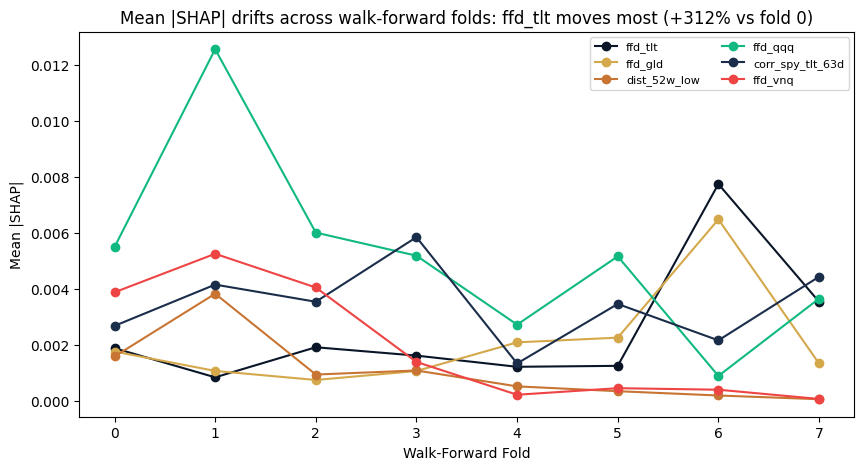

In [22]:
# Visualize importance over folds for top features
if len(fold_importances) >= 2:
    top_drift = drift_df["feature"][:6].to_list()
    fig, ax = plt.subplots(figsize=(10, 5))
    folds = fold_imp_df["fold"].to_list()
    drift_palette = [
        COLORS["blue"],
        COLORS["amber"],
        COLORS["copper"],
        COLORS["positive"],
        COLORS["slate"],
        COLORS["negative"],
    ]
    for i, feat in enumerate(top_drift):
        ax.plot(
            folds,
            fold_imp_df[feat].to_list(),
            marker="o",
            color=drift_palette[i % len(drift_palette)],
            label=feat,
            linewidth=1.5,
        )
    lead_feat = drift_df["feature"][0]
    lead_change = drift_df["max_change_pct"][0]
    ax.set_xlabel("Walk-Forward Fold")
    ax.set_ylabel("Mean |SHAP|")
    ax.set_title(
        f"Mean |SHAP| drifts across walk-forward folds: {lead_feat} moves most "
        f"(+{lead_change:.0f}% vs fold 0)"
    )
    ax.legend(fontsize=8, ncol=2)
    plt.show()

**Interpretation**: Features whose importance varies substantially across
folds may indicate regime-dependent signals. Stable importance suggests
a robust relationship; declining importance is an early warning of
concept drift warranting investigation before performance degrades.

## 12. SHAP-Based Feature Selection

Rank features by mean |SHAP|, retrain on the top-$k$, and evaluate
cross-sectional IC on the fold's **validation** window (not a sealed holdout).
Removing noise features often improves performance by reducing overfitting.

In [23]:
ranked_features = importance_df["feature"].to_list()
k_values = [5, 10, 15, len(FEATURE_COLS)]

selection_results = []
for k in k_values:
    top_k = ranked_features[:k]
    top_k_idxs = [FEATURE_COLS.index(f) for f in top_k]

    m = lgb.LGBMRegressor(**lgb_params)
    m.fit(X_train[:, top_k_idxs], y_train)
    pred = m.predict(X_test[:, top_k_idxs])
    ic = cross_sectional_ic_mean(y_test, pred, dates_test, symbols_test)
    selection_results.append({"top_k": k, "ic": round(ic, 4), "features_used": len(top_k)})

selection_df = pl.DataFrame(selection_results)
selection_df

top_k,ic,features_used
i64,f64,i64
5,NaN,5
10,-0.0091,10
15,-0.0419,15
71,-0.0265,71


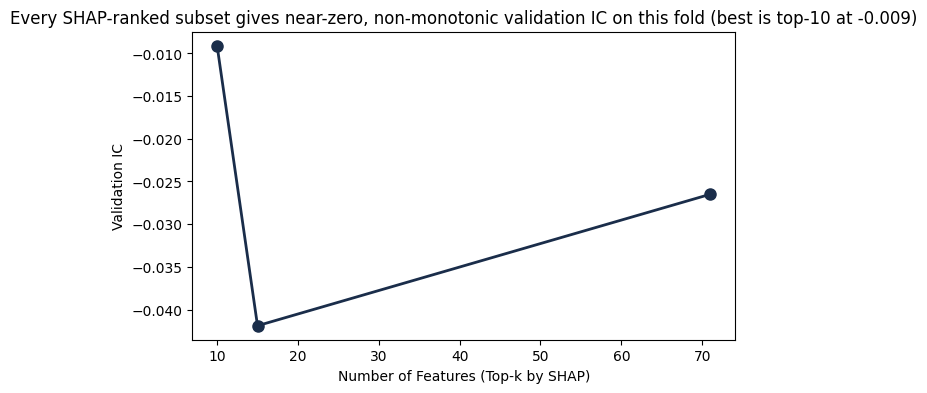

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    selection_df["top_k"],
    selection_df["ic"],
    "o-",
    color=COLORS["slate"],
    linewidth=2,
    markersize=8,
)
# NaN is a float value, not a null, so filter it explicitly (a top-k of purely
# market-level features gives an undefined cross-sectional IC — see below).
defined_ic = selection_df.filter(pl.col("ic").is_not_null() & pl.col("ic").is_not_nan())
best_row = defined_ic.sort("ic", descending=True).row(0, named=True)
ax.set_xlabel("Number of Features (Top-k by SHAP)")
ax.set_ylabel("Validation IC")
ax.set_title(
    f"Every SHAP-ranked subset gives near-zero, non-monotonic validation IC on this "
    f"fold (best is top-{best_row['top_k']} at {best_row['ic']:+.3f})"
)
plt.show()

**Reading the result**: the `selection_df` table above lists the exact values;
every SHAP-ranked subset yields a validation IC that sits near zero on this
fold, and the ordering across $k$ is not monotonic. The five-feature subset is a
special case: its top-5 features by mean |SHAP| are all market-level series
(yield-curve slope and z-score, regime duration, and the fractionally
differenced QQQ/VNQ prices), which take the **same value for every symbol on a
given date**. A model built on those alone predicts identically across the
cross-section each day, so the cross-sectional IC is undefined (reported as
`NaN`) — a useful reminder that cross-sectional signal must come from features
that vary *across* assets, not from macro state alone. Among the subsets that do
admit an IC, none is distinguishable from zero: in a regime where the
full-feature validation IC is itself indistinguishable from zero, SHAP-ranked
pruning has no signal to recover, so it neither rescues nor destroys
performance. Whether SHAP-based pruning helps is a question about folds where
the full-feature IC is positive; see `04_optuna_tuning` for the walk-forward HPO
that answers it with cross-validated evidence rather than a single fold.

### Publication Figure Artifact

The book beeswarm figure reads compact SHAP arrays for ETFs and SP500 Options
from a frozen artifact so formatting changes do not retrain GBMs.

In [25]:
BEESWARM_CASE_STUDIES = ["etfs", "sp500_options"]
MAX_BEESWARM_SAMPLES = 5000


def _build_beeswarm_panel(cs_id: str, label: str) -> dict[str, np.ndarray | str | int]:
    mds_panel = load_modeling_dataset(cs_id, label)
    df_panel = mds_panel.dataset.to_pandas()
    features_panel = mds_panel.feature_names
    split_panel = mds_panel.splits[0]

    train_mask_panel = (df_panel[mds_panel.date_col] >= split_panel["train_start"]) & (
        df_panel[mds_panel.date_col] <= split_panel["train_end"]
    )
    test_mask_panel = (df_panel[mds_panel.date_col] >= split_panel["val_start"]) & (
        df_panel[mds_panel.date_col] <= split_panel["val_end"]
    )

    X_train_panel = df_panel.loc[train_mask_panel, features_panel].values
    y_train_panel = df_panel.loc[train_mask_panel, mds_panel.label_col].values
    X_test_panel = df_panel.loc[test_mask_panel, features_panel].values
    y_test_panel = df_panel.loc[test_mask_panel, mds_panel.label_col].values

    valid_train = np.isfinite(y_train_panel)
    X_train_panel, y_train_panel = X_train_panel[valid_train], y_train_panel[valid_train]
    valid_test = np.isfinite(y_test_panel)
    X_test_panel = X_test_panel[valid_test]

    if len(X_test_panel) > MAX_BEESWARM_SAMPLES:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(len(X_test_panel), MAX_BEESWARM_SAMPLES, replace=False)
        X_test_panel = X_test_panel[idx]

    panel_model = lgb.LGBMRegressor(**lgb_params)
    panel_model.fit(X_train_panel, y_train_panel)
    panel_explainer = shap.TreeExplainer(panel_model)
    panel_shap_values = panel_explainer.shap_values(X_test_panel)

    return {
        "display_name": SHORT_NAMES.get(cs_id, cs_id),
        "feature_names": np.array(features_panel),
        "x_test": X_test_panel.astype(np.float32),
        "shap_values": panel_shap_values.astype(np.float32),
        "n_samples": len(X_test_panel),
    }


def write_figure_12_7_artifact() -> Path:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    panels = {}
    panel_ids = []
    for cs_id in BEESWARM_CASE_STUDIES:
        label = PRIMARY_LABELS.get(cs_id)
        if label is None:
            continue
        panels[cs_id] = _build_beeswarm_panel(cs_id, label)
        panel_ids.append(cs_id)

    artifact = OUTPUT_DIR / "figure_12_7_shap_beeswarm.npz"
    payload: dict[str, np.ndarray | str | int] = {"panel_ids": np.array(panel_ids)}
    for cs_id, panel in panels.items():
        for key, value in panel.items():
            payload[f"{cs_id}__{key}"] = value
    np.savez(artifact, **payload)
    return artifact


figure_12_7_artifact = write_figure_12_7_artifact()
print(f"Wrote publication figure artifact: {figure_12_7_artifact}")

Wrote publication figure artifact: ~/ml4t/code-ch12/12_gradient_boosting/output/shap_analysis/figure_12_7_shap_beeswarm.npz


## 13. Key Takeaways

**Global importance**: agreement between SHAP, PFI, and MDI on this fold
is partial. Where the three rankings agree on top features, the
explanation is robust to method choice; where they diverge, the
explanation is method-dependent and should not be reported as the
model's reasoning without naming the method that produced it.

**Interactions**: the SHAP interaction matrix shows whether predictions
decompose into approximate main effects (diagonal-dominant) or whether
regime-conditional combinations carry the signal (strong off-diagonal
cells). On this fold the interaction matrix is the diagnostic; drawing
a conclusion from it requires comparing to the same matrix on adjacent
folds, not to an a priori expectation.

**Drift detection**: the observable is each feature's per-fold mean
|SHAP|, tracked across walk-forward folds, and summarized as the
maximum percent change from the fold-0 baseline. That percentage is
only reported for features that carry real baseline importance —
near-zero-importance features are excluded because a tiny absolute
shift over a near-zero denominator inflates into a spurious "drift."
Whether an observed shift constitutes actionable drift is a threshold
question (here, 50%) whose answer depends on the universe and feature
library.

**Feature selection**: on this fold every SHAP-ranked subset yields a
validation IC near zero, and the sweep is not monotonic in $k$, so no
subset is meaningfully distinguishable from the full-feature baseline
or from zero. The pattern "IC peaks at $k < N$" therefore cannot be
demonstrated here; it appears in `04_optuna_tuning` on folds where the
full-feature IC is positive.

**Next**: See `09_xai_limitations` for explanation instability analysis,
or `11_conformal_gbm` for uncertainty quantification with prediction intervals.